In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from IPython.display import clear_output

### Данные

In [2]:
aneks = []

with open('/kaggle/input/datasets/artembez/anekdotes/anek.txt', 'r', encoding = 'utf-8') as f:
    aneks.extend(f.read().split('\n'))

In [3]:
len(aneks)

125103

In [4]:
class Vocabulary:
    def __init__(self):
        self.vocabulary = ['_', '#', '<'] # start, end, padding
        self.vocabulary.extend('абвгдеёжзийклмнопрстуфхцчшщъыьэюя')
        self.vocabulary.extend('абвгдеёжзийклмнопрстуфхцчшщъыьэюя'.upper())
        self.vocabulary.extend('0123456789 ,.!?-')

        self._idx2char = {i: char for i, char in enumerate(self.vocabulary)}
        self._char2idx = {char: i for i, char in enumerate(self.vocabulary)}

    def get_vocabulary(self):
        return self.vocabulary

    def idx2char(self, idx: int):
        if idx not in self._idx2char:
            return '<'
        return self._idx2char[idx]

    def char2idx(self, char: str):
        if char not in self._char2idx:
            return self.get_pad()
        return self._char2idx[char]

    def encode(self, text):
        result = [self.char2idx(char) for char in text]
        result = [self.get_sos()] + result + [self.get_eos()]
        return result

    def get_sos(self):
        return self.char2idx('_')

    def get_eos(self):
        return self.char2idx('#')

    def get_pad(self):
        return self.char2idx('<')
    

In [5]:
from torch.utils.data import Dataset

class Anekdotes(Dataset):
    def __init__(self, aneks):
        self.aneks = aneks
        self.vocab = Vocabulary()

    def __getitem__(self, idx):
        return torch.LongTensor(self.vocab.encode(self.aneks[idx]))

    def __len__(self):
        return len(self.aneks)

In [6]:
dataset = Anekdotes(aneks)

In [7]:
dataset[10]

tensor([ 0, 61, 22, 12, 20, 15, 12, 26, 79, 22, 18, 19, 12, 15, 79,  4, 23, 20,
        10, 23, 13, 14, 23, 81, 79, 55, 18, 15, 32, 14, 18, 79, 27,  8, 20,  8,
        11, 79,  7,  5,  3, 79, 27,  3, 21,  3, 79,  8, 16, 23, 79, 23,  7,  3,
        15, 18, 21, 32, 79,  8,  8, 79, 23, 22, 18, 19, 12, 22, 32, 81,  1])

In [8]:
aneks[10]

'Штирлиц топил буржуйку. Только через два часа ему удалось ее утопить.'

In [9]:
from torch.utils.data import random_split

train_dataset, valid_dataset = random_split(dataset, (int(len(dataset) * 0.9), len(dataset) - int(len(dataset) * 0.9)))

In [10]:
from torch.nn.utils.rnn import pad_sequence
pad_idx = dataset.vocab.get_pad()

def collate_fn(batch):
    return pad_sequence([b[:256] for b in batch], padding_value = pad_idx, batch_first = True)

In [11]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size = 256, collate_fn = collate_fn, pin_memory = True, num_workers = 4)
valid_loader = DataLoader(valid_dataset, batch_size = 256, collate_fn = collate_fn, pin_memory = True, num_workers = 4)

### RNN

### [RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)

$$h_t = \tanh\left( x_tW_{xh}^T + b_{xh} + h_{t-1}W_{hh}^T + b_{hh} \right)$$

либо если `bias=False`, то

$$h_t = \tanh\left( x_tW_{xh}^T + h_{t-1}W_{hh}^T \right)$$

Параметры:

 - `input_size` - размерность $x_i$
 - `hidden_size` - размерность $h_i$
 - `num_layers` - количество слоев (по умолчанию 1)
 - `dropout` - какой делать дропаут при количестве слоев > 1 (по умолчанию 0)
 - `bidirectional` - двунаправленная

In [12]:
layer = nn.RNN(input_size = 3, hidden_size = 6)

In [13]:
layer

RNN(3, 6)

In [14]:
print(layer.weight_hh_l0) # веса h нулевого слоя
print()
print(layer.weight_hh_l0.shape)

Parameter containing:
tensor([[-0.1748, -0.2942, -0.2650,  0.2022, -0.3171,  0.3812],
        [ 0.0650,  0.2150, -0.3191,  0.2560,  0.2103,  0.1143],
        [-0.2717, -0.2172, -0.3228, -0.3423, -0.2029,  0.0518],
        [ 0.0246,  0.0545, -0.0821,  0.2631, -0.2651,  0.3225],
        [ 0.3272, -0.1859,  0.0052,  0.1292, -0.3174, -0.0564],
        [ 0.2164,  0.0398, -0.1971,  0.3616,  0.1354, -0.1863]],
       requires_grad=True)

torch.Size([6, 6])


In [15]:
print(layer.weight_ih_l0)
print()
print(layer.weight_ih_l0.shape)

Parameter containing:
tensor([[-0.2871,  0.2224, -0.3304],
        [ 0.3678,  0.2772,  0.1215],
        [-0.1543, -0.3203, -0.3785],
        [-0.1833,  0.2259, -0.0613],
        [ 0.1892, -0.3246, -0.1047],
        [-0.1471,  0.2664,  0.0234]], requires_grad=True)

torch.Size([6, 3])


In [16]:
print(layer.bias_hh_l0)
print()
print(layer.bias_hh_l0.shape)

Parameter containing:
tensor([-0.3526, -0.2494,  0.1205, -0.2923, -0.1319,  0.3008],
       requires_grad=True)

torch.Size([6])


In [17]:
print(layer.bias_ih_l0)
print()
print(layer.bias_ih_l0.shape)

Parameter containing:
tensor([-0.3448,  0.2691, -0.2668, -0.0461, -0.1137,  0.1066],
       requires_grad=True)

torch.Size([6])


In [18]:
batch_size = 5
seq_len = 7
input_dim = 3

layer = nn.RNN(input_size = 3, hidden_size = 6, batch_first = True)

x = torch.randn(batch_size, seq_len, input_dim)

hs, h_last = layer(x)

print(hs)
print()
print(hs.shape)


print(h_last)
print()
print(h_last.shape)

tensor([[[-0.3749, -0.1236, -0.1879,  0.2151,  0.6101,  0.2592],
         [-0.3009,  0.4182, -0.6243, -0.5529, -0.0135,  0.0758],
         [ 0.3047,  0.5323, -0.2418,  0.0771, -0.4181, -0.1201],
         [-0.4514,  0.5731, -0.3953, -0.4217, -0.0718, -0.2904],
         [-0.3885, -0.5780, -0.4728,  0.2623,  0.2026, -0.0635],
         [ 0.1164,  0.4891,  0.0222, -0.5290,  0.7101,  0.6347],
         [-0.1545,  0.5169, -0.2751, -0.0907, -0.0222, -0.3005]],

        [[-0.0556,  0.2505, -0.1362,  0.3916,  0.3491,  0.2900],
         [-0.1799,  0.0871,  0.3000, -0.1603,  0.8582,  0.5430],
         [-0.2274,  0.7816, -0.2001, -0.6337,  0.3975, -0.0714],
         [ 0.0466,  0.1518, -0.0081,  0.0899,  0.3520, -0.0118],
         [-0.1669,  0.4482, -0.2800, -0.1810,  0.3246,  0.1894],
         [-0.4860,  0.1686, -0.5429, -0.5198,  0.0582, -0.2684],
         [ 0.4825,  0.2929,  0.1535,  0.2965,  0.3229,  0.4115]],

        [[-0.2783,  0.5288, -0.3028, -0.2314,  0.2556,  0.0456],
         [ 0.0290,  0

### GRU

### [GRU](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)

$$r_t = \sigma\left( x_t W_{xr}^T + b_{xr} + h_{t-1}W_{hr}^T + b_{hr} \right)$$
$$z_t = \sigma\left( x_t W_{xz}^T + b_{xz} + h_{t-1}W_{hz}^T + b_{hz} \right)$$
$$\hat{h_t} = \tanh\left( x_tW_{xh}^T + b_{xh} + r_t * (h_{t-1}W_{hh}^T + b_{hh}) \right)$$
$$h_t = (1 - z_t) * \hat{h_t} + z_t * h_{t-1}$$

Параметры такие же как у RNN.

In [19]:
layer = nn.GRU(input_size = 3, hidden_size = 6)
layer

GRU(3, 6)

In [20]:
print(layer.weight_hh_l0)
print()
print(layer.weight_hh_l0.shape)

Parameter containing:
tensor([[-0.4016, -0.2008, -0.0117, -0.1718,  0.0912,  0.3410],
        [-0.3090, -0.2423, -0.1759, -0.1650, -0.0582,  0.1935],
        [-0.1471,  0.1246, -0.2198,  0.2938, -0.2001, -0.3285],
        [-0.2678,  0.3845, -0.0318,  0.2147, -0.0200, -0.1047],
        [-0.2002,  0.2073,  0.3304,  0.2081,  0.0156, -0.2778],
        [-0.0031,  0.3116, -0.2968,  0.2626, -0.0848,  0.1022],
        [-0.3850, -0.1066, -0.0174,  0.3303, -0.0973,  0.0466],
        [-0.3440, -0.3830, -0.3102,  0.1990, -0.0398, -0.3785],
        [ 0.3932, -0.1029,  0.2166,  0.0246, -0.0642, -0.3652],
        [-0.3267,  0.0521, -0.0780,  0.3666,  0.0297, -0.3495],
        [-0.3760,  0.3329,  0.0280,  0.2668, -0.0095, -0.0766],
        [-0.3598, -0.3074, -0.2913,  0.0740, -0.1261,  0.3707],
        [ 0.0483, -0.1192, -0.3378, -0.0616,  0.0195, -0.0632],
        [-0.2735, -0.0139,  0.3281,  0.2241,  0.3918,  0.3441],
        [-0.1462,  0.1193,  0.0036,  0.3827,  0.2120, -0.0021],
        [-0.3662, 

In [21]:
print(layer.weight_ih_l0)
print()
print(layer.weight_ih_l0.shape)

Parameter containing:
tensor([[-0.0337, -0.1464, -0.1459],
        [ 0.1476,  0.0300,  0.2643],
        [-0.2439,  0.3904, -0.0645],
        [ 0.1369,  0.3589,  0.3388],
        [-0.1105, -0.2481, -0.3942],
        [-0.1747,  0.0199,  0.2927],
        [ 0.1106, -0.1754,  0.1897],
        [ 0.1220, -0.1035, -0.2631],
        [-0.0432, -0.1355,  0.3446],
        [ 0.2352, -0.1515,  0.2120],
        [ 0.2483, -0.2141, -0.1711],
        [ 0.2595,  0.3178, -0.0380],
        [-0.1863,  0.2863, -0.3216],
        [-0.3323,  0.1313,  0.3037],
        [-0.2433,  0.3246,  0.3930],
        [-0.1395,  0.1236,  0.3601],
        [ 0.2640, -0.0917,  0.0691],
        [ 0.2691,  0.3289, -0.0048]], requires_grad=True)

torch.Size([18, 3])


In [22]:
print(layer.bias_hh_l0)
print()
print(layer.bias_hh_l0.shape)

Parameter containing:
tensor([-0.1839,  0.1629, -0.1673, -0.1381,  0.0465, -0.3531, -0.3605, -0.1883,
         0.2096,  0.1388,  0.3314,  0.1097, -0.0918,  0.2466,  0.3810,  0.2223,
         0.1350, -0.1160], requires_grad=True)

torch.Size([18])


In [23]:
print(layer.bias_ih_l0)
print()
print(layer.bias_ih_l0.shape)

Parameter containing:
tensor([-0.1196, -0.3559, -0.4082,  0.3870, -0.1970,  0.3043, -0.2807,  0.3937,
         0.3642, -0.1580,  0.3641, -0.1016,  0.1921, -0.1378, -0.1165, -0.1490,
        -0.1840, -0.3578], requires_grad=True)

torch.Size([18])


### LSTM

### [LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

Более страшные формулы, все в целом очень похоже на GRU. Параметры те же.

In [24]:
layer = nn.LSTM(input_size = 3, hidden_size = 6)
layer

LSTM(3, 6)

### AnekdotesRNN

In [25]:
class AnekdotesRNN(nn.Module):
    def __init__(self, num_tokens: int, emb_size: int = 256, hidden_size : int = 256):
        super().__init__()
        # каждый токен кодируем вектором размерности emb_size
        # padding_idx - индекс нулевого слова, обновляться не будет
        self.embedding = nn.Embedding(num_tokens, emb_size, padding_idx = pad_idx)

        self.rnn = nn.LSTM(
            input_size = emb_size,
            hidden_size = hidden_size,
            num_layers = 3,
            dropout = 0.3,
            batch_first = True
        )

        self.output = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(),
            nn.Linear(hidden_size, num_tokens)
        )

    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.rnn(x)
        x = self.output(x)

        return x

In [26]:
model = AnekdotesRNN(num_tokens = len(dataset.vocab.get_vocabulary()))

### Функции для обучения
в качестве таргета мы берем последовательность, начиная с 1 элемента, потому что предсказываем следующий токен
вход на обучение: [1, 2, 3, 4]  
таргет: [2, 3, 4, 5]

In [27]:
from tqdm import tqdm

def train(model):
    model.train()

    train_loss = 0
    
    for x in tqdm(train_loader, desc = 'Train'):
        x = x.to(device)
        
        optimizer.zero_grad()

        output = model(x[:, :-1]).transpose(1, 2)
        
        loss = loss_fn(output, x[:, 1:])

        train_loss += loss.item()

        loss.backward()
        optimizer.step()

    train_loss /= len(train_loader)

    return train_loss

Поскольку мы используем `nn.CrossEntropyLoss`, то посмотрим в каком размере она ожидает входы:

 - Input: Shape $(C)$, $(N, C)$ or $(N, C, d_1, d_2, ..., d_K)$ with $K \geq 1$ in the case of $K$-dimensional loss.
 - Target: $(N)$ or $(N, d_1, d_2, ..., d_K)$ with $K \geq 1$ in the case of $K$-dimensional loss where each value should be between $[0, C)$.

In [28]:
x = next(iter(train_loader))
output = model(x[:, :-1])
print(output.shape)
print(x[:, 1:].shape)

print()

print(output.transpose(1, 2).shape)

torch.Size([256, 255, 85])
torch.Size([256, 255])

torch.Size([256, 85, 255])


In [29]:
print(len(dataset.vocab.get_vocabulary()))

85


In [30]:
@torch.inference_mode()
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    for x in tqdm(loader, desc = 'Evaluation'):
        x = x.to(device)

        output = model(x[:, :-1]).transpose(1, 2)

        loss = loss_fn(output, x[:, 1:])

        total_loss += loss.item()

    total_loss /= len(loader)
    return total_loss

In [31]:
def plot_stats(
    train_loss: list[float],
    valid_loss: list[float],
    title
):
    plt.figure(figsize = (16, 10))
    plt.title(title)
    plt.plot(train_loss, label = 'Train loss')
    plt.plot(valid_loss, label = 'Valid loss')
    plt.legend()
    plt.grid()
    plt.show()

In [32]:
def whole_train_value_cycle(
    model,
    title: str,
    num_epochs = 3,
):
    train_loss_history = []
    valid_loss_history = []

    for epoch in range(num_epochs):
        train_loss = train(model)
        valid_loss = evaluate(model, valid_loader)

        train_loss_history.append(train_loss)
        valid_loss_history.append(valid_loss)

        clear_output(wait = True)

        plot_stats(train_loss_history, valid_loss_history, title)

### Обучение

In [33]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

print(device)
print(torch.cuda.get_device_name() if torch.cuda.is_available() else None)

cuda:0
Tesla T4


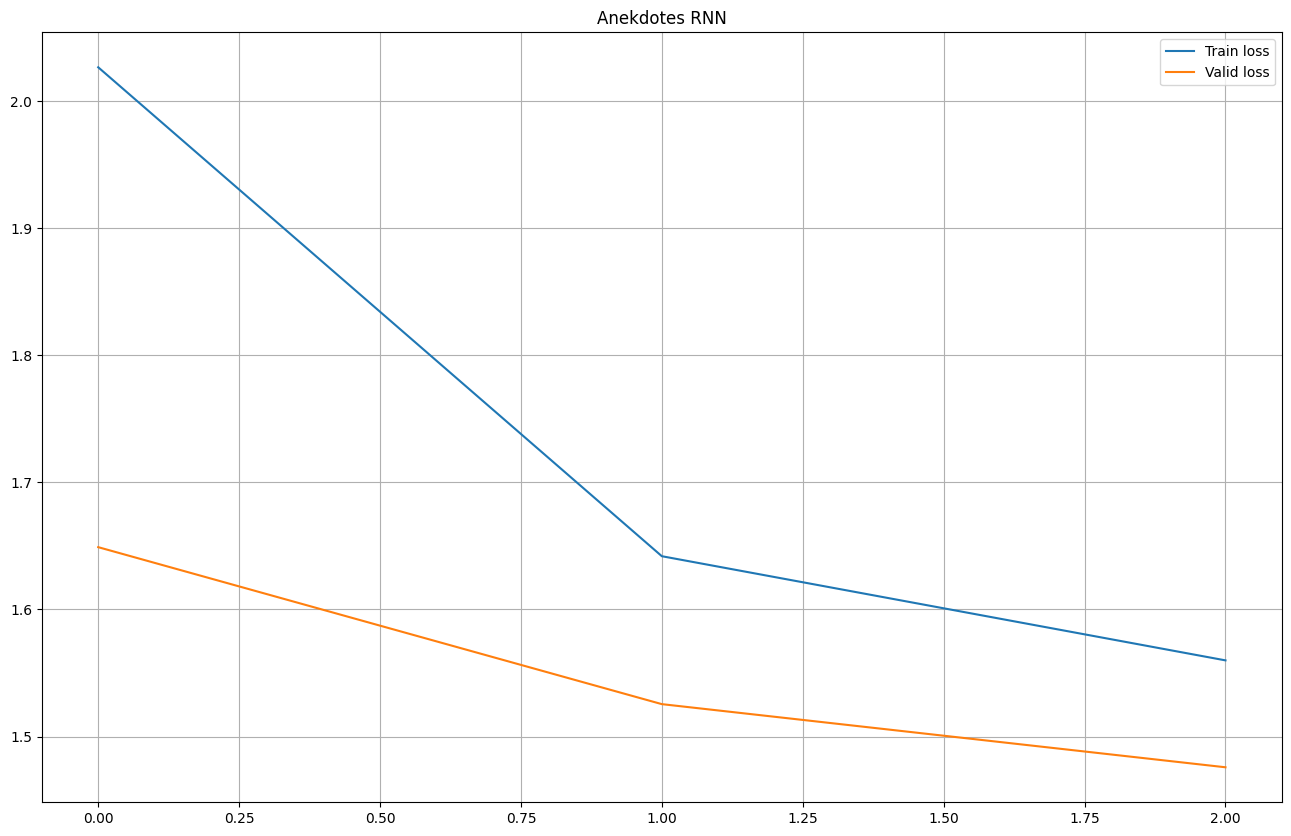

In [35]:
from torch.optim import Adam
model = model.to(device)

optimizer = Adam(model.parameters(), lr = 5e-3)
loss_fn = nn.CrossEntropyLoss(ignore_index = pad_idx)

whole_train_value_cycle(model, 'Anekdotes RNN', 3)

### Генерация анекдотов

In [36]:
eos = dataset.vocab.get_eos()

def ids2string(ids):
    result = []

    for _ in ids:
        if _ != eos:
            result.append(dataset.vocab.idx2char(_))
    return "".join(result)

def batch2string(ids, prefix):
    ans = ""
    for i, substr in enumerate(ids):
        ans += prefix + ids2string(substr.tolist())

        if i != len(ids) - 1:
            ans += '\n'
    return ans

def pick_by_distributions(logits):
    probs = torch.exp(logits)
    sample = torch.distributions.Categorical(probs).sample()
    return sample

@torch.inference_mode()
def get_continuation(model, prefix: str = '', max_len: int = 150, count = 10, temperature: float = 1):
    x = torch.LongTensor([dataset.vocab.encode(prefix)[:-1]] * count).to(device)
    model.eval()

    logits = model(x)[:, -1, :]
    outs = pick_by_distributions(logits / temperature).unsqueeze(1)

    for i in range(max_len):
        x = torch.cat([x, outs], dim = 1)
        logits = model(x)[:, -1, :]

        outs = pick_by_distributions(logits / temperature).unsqueeze(1)
    print(batch2string(x[:, len(prefix) + 1:], prefix + '|' ))

In [37]:
get_continuation(model, prefix = 'Приходит как-то', temperature = 0.5)

Приходит как-то| принять коллега - это когда нет полицейские пришели как директора молодого принципа.ерное всего, чтобы не спрашивает- А ты так вы своей девушке хоте
Приходит как-то| новый женщины с головами, но сейчас сильно совсем не вывести себя в стране.учили после машина сборного парашюта. В сутти что-то поставил свои больше
Приходит как-то| стал противодания с парком, чтобы не от которого за получились в подъездах получить возраст, а она не подходит на хорошо.ы уже за столовой получаетс
Приходит как-то| дома на искусственном году дома просто не принимает.ерить есть получается в детстве за три человека, как ее построили себя проверять мужчина.арья и
Приходит как-то| приходит по морду под воду Кармана и говорит- Дай мы помогите полученные мужчины?- Она все просто понимаешь, что я получает от своими постели и посмо
Приходит как-то| дома на все время глаза.ы дождь получается как ты и не будет поднимать.ы в случае можно на холодильнике на себя сейчас с ними из коронавируса.ерег
Приход

In [38]:
get_continuation(model, prefix = 'Штирлиц', temperature = 0.7)

Штирлиц| спрашивает подруги- Просто ты началось вернуться в грудь, что у тебя за того, что не заметка?- Ну, почему шесть принял бы вы обладать порности, а она
Штирлиц| - это страшный...ердители на 100 слова в хорошего необходимого, но уже воздумали себе в больнице.антально делают из головы, то выступает давать что
Штирлиц| на пришел с Ябами, подарил... Выполнение ли принятия было не бесполезно.тороз с утронину - а прокурора...укает на полнолещую порядочную семью.ороч
Штирлиц| произошла, написать первой и тех, кто попала в журналисты в последний старый книгов - папа совсем не замечал.олот ничего не мог начать бросить до то
Штирлиц| давно все совместные принятые новых постоянно переводит девушке курить.ез интернета слушать взять делать по лесу, что я на очень разместительную мес
Штирлиц| так диета сейчас на немного по работу просто выйду с собой снять их не построена.уста на все муж, то в команды ни она дорогами поймет.аня по семья 
Штирлиц| сняли руки ответил и спрашивает у России. Обыч

In [39]:
for idx in [10, 150, 772, 1835]:
    print(aneks[idx])
    print()
    get_continuation(model, prefix = ' '.join(aneks[idx].split()[:5]), temperature = 0.5)
    print()
    print('-' * 60)
    print()

Штирлиц топил буржуйку. Только через два часа ему удалось ее утопить.

Штирлиц топил буржуйку. Только через| молодой принципе в получке странное выбирает на шесть.юрмен- А почему тебе стал бы уже подарить с нами и получилось?- Собака, не понял, что на прост
Штирлиц топил буржуйку. Только через| после дома приходит с собаками.ара на столе в рассказываете мальчика- Что хочешь в больше становится?- Нет, вы в детском день тут все равно после те
Штирлиц топил буржуйку. Только через| получится в правильной пациентов.юшел впечатление и после пришлось из жизни.аска со скорой лапкой было в том, что он после обои женится и руку.оро
Штирлиц топил буржуйку. Только через| перед стать мама понять, что у них не поймал приключение, на день продавец в детстве и смотреть.орма города - стало выпить лишь получаться в порядке
Штирлиц топил буржуйку. Только через| себя не понимает, что я попала, что на котором за маме продать не принять выбирает по старушку только работать и вы стали можно проблема.ы привет